In [2]:
import pandas as pd

df = pd.read_csv('student-mat.csv', sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
import numpy as np

# Criando variável alvo
# 1 = aprovado
# 0 = reprovado

df['resultado'] = np.where(df['G3'] >= 10, 1, 0)

df[['G3', 'resultado']].head()

,G3,resultado
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
import numpy as np

df['resultado'] = np.where(df['G3'] >= 10, 1, 0)

df[['G3', 'resultado']].head()

,G3,resultado
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Seleciona colunas categóricas
colunas_categoricas = df.select_dtypes(include='object').columns

# Converte texto para número
for coluna in colunas_categoricas:
    df[coluna] = le.fit_transform(df[coluna])

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,resultado
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


In [9]:
from sklearn.preprocessing import LabelEncoder

# Criando objeto do encoder
le = LabelEncoder()

# Selecionando colunas categóricas
colunas_categoricas = df.select_dtypes(include='object').columns

# Convertendo texto para número
for coluna in colunas_categoricas:
    df[coluna] = le.fit_transform(df[coluna])

# Mostrando resultado
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,resultado
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


In [10]:
print("Linhas antes:", df.shape[0])

# Removendo linhas duplicadas
df = df.drop_duplicates()

print("Linhas depois:", df.shape[0])

Linhas antes: 395
Linhas depois: 395


In [11]:
# Variáveis de entrada
X = df.drop(['G3', 'resultado'], axis=1)

# Variável alvo
y = df['resultado']

print(X.head())
print(y.head())

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0       0    0   18        1        0        0     4     4     0     4  ...   
1       0    0   17        1        0        1     1     1     0     2  ...   
2       0    0   15        1        1        1     1     1     0     2  ...   
3       0    0   15        1        0        1     4     2     1     3  ...   
4       0    0   16        1        0        1     3     3     2     2  ...   

   romantic  famrel  freetime  goout  Dalc  Walc  health  absences  G1  G2  
0         0       4         3      4     1     1       3         6   5   6  
1         0       5         3      3     1     1       3         4   5   5  
2         0       4         3      2     2     3       3        10   7   8  
3         1       3         2      2     1     1       5         2  15  14  
4         0       4         3      2     1     2       5         4   6  10  

[5 rows x 32 columns]
0    0
1    0
2    1
3    1
4    1
Name:

In [12]:
from sklearn.model_selection import train_test_split

# Separando teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

# Separando treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (275, 32)
Validação: (60, 32)
Teste: (60, 32)


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Criando modelo
modelo = RandomForestClassifier(random_state=42)

# Treinando modelo
modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [14]:
from sklearn.metrics import accuracy_score

# Fazendo previsões
y_val_pred = modelo.predict(X_val)

# Calculando acurácia
acuracia_val = accuracy_score(y_val, y_val_pred)

print("Acurácia validação:", acuracia_val)

Acurácia validação: 0.9333333333333333


In [15]:
# Previsões no conjunto de teste
y_test_pred = modelo.predict(X_test)

# Acurácia final
acuracia_teste = accuracy_score(y_test, y_test_pred)

print("Acurácia teste:", acuracia_teste)

Acurácia teste: 0.9166666666666666


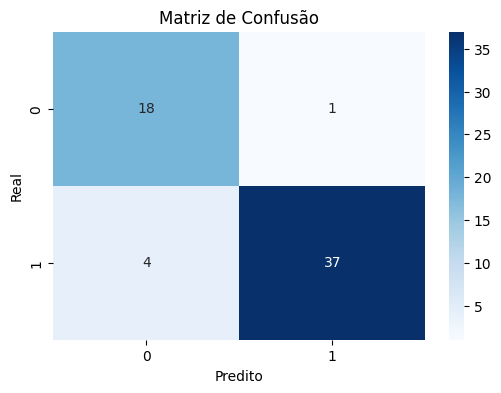

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Criando matriz
matriz = confusion_matrix(y_test, y_test_pred)

# Plotando gráfico
plt.figure(figsize=(6,4))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

plt.show()

In [17]:
# Pegando uma amostra
nova_amostra = X_test.iloc[0:1]

# Fazendo previsão
predicao = modelo.predict(nova_amostra)

# Resultado
if predicao[0] == 1:
    print("Aluno provavelmente APROVADO")
else:
    print("Aluno provavelmente REPROVADO")

Aluno provavelmente REPROVADO


# Esteira de Machine Learning - Student Performance

## Descrição

Projeto desenvolvido para prever aprovação de estudantes utilizando Machine Learning.

## Tecnologias

- Python
- Pandas
- Scikit-Learn
- Google Colab

## Modelo utilizado

Random Forest Classifier

In [19]:
readme = """
# Esteira de Machine Learning - Student Performance

## Descrição

Projeto desenvolvido para prever aprovação de estudantes utilizando Machine Learning.

## Tecnologias

- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn
- Google Colab

## Modelo utilizado

Random Forest Classifier

## Autor

Gabriel Silvano Vieira
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README criado com sucesso!")

README criado com sucesso!
